In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

In [3]:
command= ['python3 train.py --run_number -1 --task_name var_copy --layer1 TF --layer2 TF --embed_dim 12 --window 20 --num_heads 1 --state_dim 1 --num_epochs 100 --save_path interpret.pt']
command

['python3 train.py --run_number -1 --task_name var_copy --layer1 TF --layer2 TF --embed_dim 12 --window 20 --num_heads 1 --state_dim 1 --num_epochs 100 --save_path interpret.pt']

In [4]:
def run_command(cmd):
    """Run a single shell command and return (cmd, returncode, stdout, stderr)."""
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return cmd, result.returncode, result.stdout, result.stderr

run_command(command)

(['python3 train.py --run_number -1 --task_name var_copy --layer1 TF --layer2 TF --embed_dim 12 --window 20 --num_heads 1 --state_dim 1 --num_epochs 100 --save_path interpret.pt'],
 0,
 'Generating Data\n- Sequence Num: 0\n- Sequence Num: 8000\n- Sequence Num: 16000\n- Sequence Num: 24000\n- Sequence Num: 32000\n- Sequence Num: 40000\n- Sequence Num: 48000\n- Sequence Num: 56000\nStarting work for results/data_100_5_30/run-1.pt\nLoss: 2.7080, Acc: 0.2483\n',
 '')

In [16]:
import torch
import matplotlib.pyplot as plt
from generate import generate_data, set_task_specific_parameters
from models.transformer import generate_mask, scaled_dot_product_attention, SimpleHandmadeTFLayer
from models.ssm import SimpleSSMLayer

In [17]:
class args:
    batch_size = 1
    batches_per_epoch = 1
    task_name = "var_copy"
    min_num_token = 5
    num_numbers = 5
    num_vocab = 30
    sequence_len = 100

set_task_specific_parameters(args)

In [18]:
in_data, out_data = generate_data(args)
in_data

Generating Data
- Sequence Num: 0


tensor([[18, 17, 11, 19,  6, 22,  6, 25, 38,  5, 39, 39, 24, 38,  9, 29, 20, 14,
          5,  5,  5, 21, 14,  5, 36, 35, 28,  8,  5,  8,  6, 25, 38,  9,  7, 16,
         30, 14, 13,  7, 18, 14, 30,  5,  7, 26,  6, 27, 39, 35, 17, 10,  9, 22,
         35, 21, 22, 24, 39, 39, 18, 30,  5,  8,  5,  8, 25, 39,  5,  6, 28,  8,
         34, 19, 31,  7,  6, 12, 36, 11,  8, 23, 10, 30, 35, 17, 19, 14,  8, 10,
         38, 13, 13, 38, 17,  9, 29,  5, 23, 23]], dtype=torch.int32)

In [19]:
model = torch.load("saved_models/interpret.pt", weights_only=False).to('cuda:0')
mask = generate_mask(args.sequence_len).to('cuda:0')

In [20]:
model

HybridModel(
  (embedding): Embedding(41, 12)
  (layers): ModuleList(
    (0-1): 2 x SimpleHandmadeTFLayer(
      (transformer_encoder): TransformerHead(
        (mha): MultiHeadAttention(
          (q_proj): Linear(in_features=12, out_features=12, bias=True)
          (k_proj): Linear(in_features=12, out_features=12, bias=True)
          (v_proj): Linear(in_features=12, out_features=12, bias=True)
          (out_proj): Linear(in_features=12, out_features=12, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (norm1): LayerNorm((12,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((12,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=12, out_features=12, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=12, out_features=12, bias=True)
        )
        (dropout): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (decoder): Linear(i

In [21]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

4193

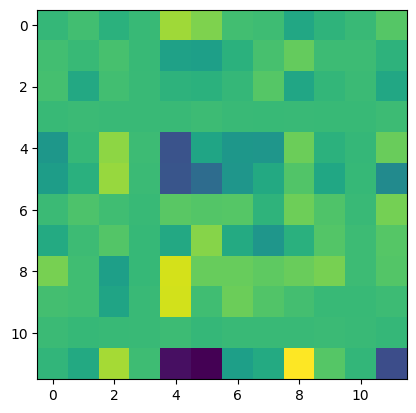

In [22]:
if type(model.layers[0]) == SimpleHandmadeTFLayer:
    layer0 = model.layers[0].transformer_encoder
    q_proj = layer0.mha.q_proj.weight.to('cpu').detach()
    k_proj = layer0.mha.k_proj.weight.to('cpu').detach()

    plt.imshow(torch.matmul(q_proj, k_proj.transpose(-2, -1)))

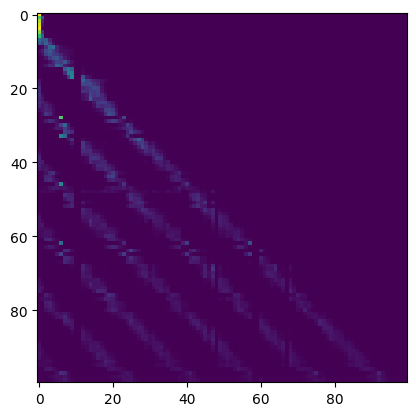

In [23]:
if type(model.layers[0]) == SimpleHandmadeTFLayer:
    x = model.embedding(in_data.to('cuda:0')) * (model.embedding.embedding_dim ** 0.5)
            
    if model.positional_encoding == "sine":
        x = x + model.pos_encoder(x) # For the sinusoidal positional encoding class
    if model.positional_encoding == "learned":
        x = x + model.pos_encoder # For the learned positional encodings
    
    # xx = x.permute(1, 0, 2)
    xx = x
    
    x_norm = model.layers[0].transformer_encoder.norm1(xx)
    
    mha = model.layers[0].transformer_encoder.mha
    B, T, _ = x_norm.size()
    q = mha.q_proj(x_norm).view(B, T, mha.num_heads, mha.head_dim).transpose(1, 2)
    k = mha.k_proj(x_norm).view(B, T, mha.num_heads, mha.head_dim).transpose(1, 2)
    v = mha.v_proj(x_norm).view(B, T, mha.num_heads, mha.head_dim).transpose(1, 2)
    
    attn_output, attn_weights = scaled_dot_product_attention(q, k, v, mask)

    head_number = 0
    plt.imshow(attn_weights[0,head_number].to('cpu').detach())

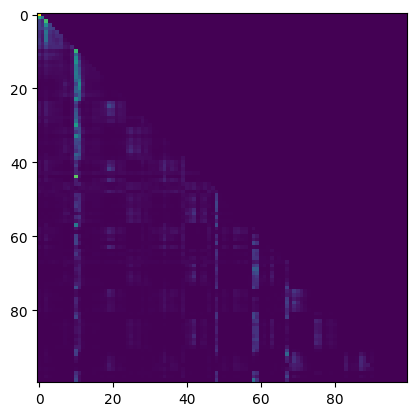

In [24]:
if type(model.layers[1]) == SimpleHandmadeTFLayer:
    x = model.embedding(in_data.to('cuda:0')) * (model.embedding.embedding_dim ** 0.5)
            
    if model.positional_encoding == "sine":
        x = x + model.pos_encoder(x) # For the sinusoidal positional encoding class
    if model.positional_encoding == "learned":
        x = x + model.pos_encoder # For the learned positional encodings

    x = model.layers[0](x, mask)
    
    # xx = x.permute(1, 0, 2)
    xx = x
    
    x_norm = model.layers[1].transformer_encoder.norm1(xx)
    
    mha = model.layers[1].transformer_encoder.mha
    B, T, _ = x_norm.size()
    q = mha.q_proj(x_norm).view(B, T, mha.num_heads, mha.head_dim).transpose(1, 2)
    k = mha.k_proj(x_norm).view(B, T, mha.num_heads, mha.head_dim).transpose(1, 2)
    v = mha.v_proj(x_norm).view(B, T, mha.num_heads, mha.head_dim).transpose(1, 2)
    
    attn_output, attn_weights = scaled_dot_product_attention(q, k, v, mask)

    head_number = 0
    plt.imshow(attn_weights[0,head_number].to('cpu').detach())

In [25]:
loss_mask = (out_data != args.vocab_size-1)
acc = torch.sum(loss_mask.to("cuda:0") & ((torch.argmax(model(in_data.to("cuda:0"), mask.to("cuda:0")), dim=-1) - out_data.to("cuda:0")) == 0)).item()
acc /= loss_mask.sum()

In [26]:
acc

tensor(0.1383)